# Calculating hosting capacity for SDG&E
Use the hosting capacity calculation methodology from Brockway et al (2021) to calculate the hosting capacity for SDG&E at the census tract level. 

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from shapely.geometry import MultiLineString
import matplotlib.pyplot as plt

### Load in data

In [2]:
# read in feederline data
sdge_feederlines = gpd.read_file("../../../../capstone/electrigrid/data/utilities/sandiego_grid/gen_cap_lines_sdge.geojson")

# read in multifamily data
sdge_multifamily = gpd.read_file("../../../../capstone/electrigrid/data/building_zillow_merges/sdcounty_buildings/multi_summed_units_sd.geojson")

# read in the single family data  
sdge_singlefamily = gpd.read_file("../../../../capstone/electrigrid/data/building_zillow_merges/sdcounty_buildings/sdge_singlefamily.geojson")

# read in the census tract data
census_tracts = gpd.read_file("../../../../capstone/electrigrid/data/census/tl_2025_06_tract/tl_2025_06_tract.shp")

# load in shapefile for extent of SDGE
utility_ter = gpd.read_file("../../../../capstone/electrigrid/data/utilities/IOU_shapefiles.geojson")

# Clip the census tract data to SDGE 

In [3]:
# view the utility data frame
utility_ter.head()

,OBJECTID,Acronym,Utility,AgencyNum,Type,URL,Phone,Address,HIFLD_ID,Sales_GWh_1990,...,Sales_GWh_2019,Sales_GWh_2020,Sales_GWh_2021,Sales_GWh_2022,Sales_GWh_2023,Sales_GWh_2024,Sales_GWh_2025,OnlineName,Audit,geometry
0,1,,PacifiCorp,71026.0,IOU,https://www.pacificorp.com/,(503) 813-5000,"825 NE Multnomah Street, Suite 2000 Portland, ...",14354,736.955156,...,742.775668,762.225388,794.358238,801.710660,774.312862,None,None,None,None,"MULTIPOLYGON Z (((-124.20211 41.74485 0.00000,..."
1,2,,Liberty Utilities,84372.0,IOU,http://www.libertyutilities.com/west/?region=C...,800.782.2506,"933 Eloise Ave South Lake Tahoe, CA 96150",57483,426.373385,...,564.199718,553.802343,559.771745,558.609575,539.033661,None,None,None,None,"POLYGON Z ((-120.08497 39.70865 0.00000, -120...."
2,3,SCE,Southern California Edison,86250.0,IOU,https://www.sce.com/,(818) 302-1212,"2244 Walnut Grove Avenue Rosemead, CA 91770-3714",17609,71016.547845,...,81183.999994,81054.000005,81132.999996,82971.000004,76840.077169,None,None,None,None,"MULTIPOLYGON Z (((-118.60361 33.47801 0.00000,..."
3,4,PG&E,Pacific Gas & Electric Company,71021.0,IOU,https://www.pge.com/,(415) 973-7000,"77 Beale Street San Francisco, CA 94105",14328,70036.326445,...,78389.925613,78518.835139,78438.000003,77887.000005,72932.833237,None,None,None,None,"MULTIPOLYGON Z (((-120.87195 35.21664 0.00000,..."
4,5,SDG&E,San Diego Gas & Electric,80402.0,IOU,https://www.sdge.com/,(619) 696-2000,"P.O. Box 129831 San Diego, CA 92112-9831",16609,14396.900280,...,17681.971922,17444.765817,17444.765817,17867.262050,16982.218070,None,None,None,None,"MULTIPOLYGON Z (((-117.12961 32.62193 0.00000,..."


In [4]:
# filter to only sdge 
shape_sdge = utility_ter[utility_ter['Acronym'] == 'SDG&E'] 

# check the crs
shape_sdge = shape_sdge.to_crs('EPSG:3310')

In [5]:
census_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,065,042516,06065042516,1400000US06065042516,425.16,Census Tract 425.16,G5020,S,973130,0,+33.9227363,-117.2393879,"POLYGON ((-117.24375 33.92818, -117.24323 33.9..."
1,06,065,042716,06065042716,1400000US06065042716,427.16,Census Tract 427.16,G5020,S,2698784,711913,+33.6865062,-117.2551285,"POLYGON ((-117.27209 33.68473, -117.27117 33.6..."
2,06,065,042717,06065042717,1400000US06065042717,427.17,Census Tract 427.17,G5020,S,6425166,145210,+33.6997108,-117.2534257,"POLYGON ((-117.26908 33.70438, -117.26882 33.7..."
3,06,065,042902,06065042902,1400000US06065042902,429.02,Census Tract 429.02,G5020,S,43393952,0,+33.7493422,-117.3068291,"POLYGON ((-117.34733 33.78247, -117.34731 33.7..."
4,06,065,042903,06065042903,1400000US06065042903,429.03,Census Tract 429.03,G5020,S,44642454,0,+33.8027798,-117.3133054,"POLYGON ((-117.36332 33.82940, -117.36331 33.8..."


In [6]:
# change the crs of the census tract data
census_tracts = census_tracts.to_crs('EPSG:3310')

# add a check before performing geospatial clipping
assert census_tracts.crs == shape_sdge.crs

# mask the census tract to the sdge area
census_tracts = census_tracts.clip(shape_sdge)


# Link the homes to the nearest feederline

In [7]:

# change the crs to a projected CRS
sdge_feederlines = sdge_feederlines.to_crs("EPSG:3310")
sdge_singlefamily = sdge_singlefamily.to_crs("EPSG:3310")

# add a check
assert sdge_feederlines.crs == sdge_singlefamily.crs


# index the data
sdge_feederlines.sindex
sdge_singlefamily.sindex

# spatial join
sdge_singlefamily_linked = gpd.sjoin_nearest(sdge_singlefamily, 
                                        sdge_feederlines, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

In [8]:
# change the crs to a projected CRS
sdge_multifamily = sdge_multifamily.to_crs("EPSG:3310")

# add a check
assert sdge_feederlines.crs == sdge_multifamily.crs

# index the data
sdge_feederlines.sindex
sdge_multifamily.sindex

# spatial join
sdge_multifamily_linked = gpd.sjoin_nearest(sdge_multifamily, 
                                        sdge_feederlines, 
                                        how="left", 
                                        lsuffix='_left', 
                                        rsuffix='_right',
                                        distance_col='dist_to_line_m')

# Create line length column

Our data analysis will need length data for each line segment. Let's calculate the lengths.

In [9]:
# create length column in metres
sdge_singlefamily_linked['LENGTH (M)'] = sdge_singlefamily_linked.length
sdge_multifamily_linked['LENGTH (M)'] = sdge_multifamily_linked.length

# Map all of the data sources

<Axes: >

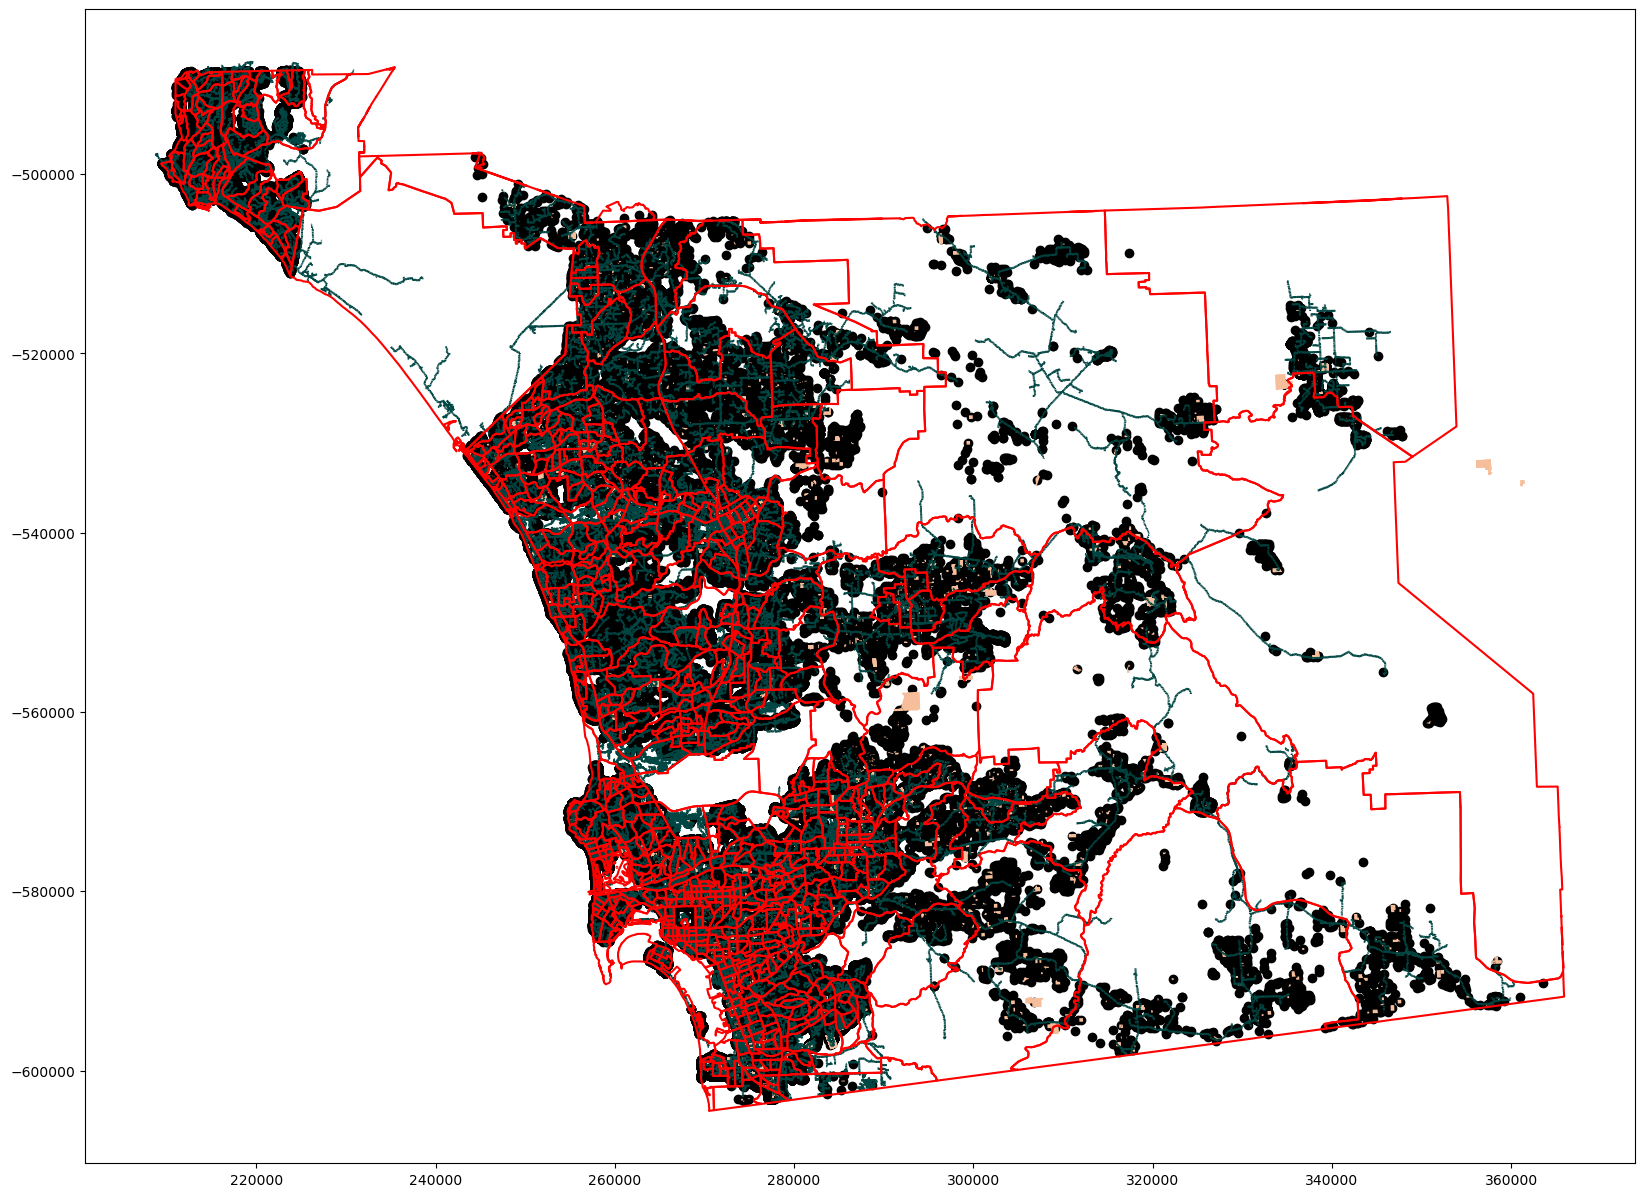

In [10]:
# plot all of the data sources to ensure everything looks accurate 
fig, ax = plt.subplots(figsize=(20, 20))

# ax.axis('off')

sdge_singlefamily_linked.plot(ax=ax, 
                    color='black')

sdge_multifamily_linked.plot(ax=ax, 
                    color='#F6BE9A')

sdge_feederlines.plot(ax=ax, 
                      color='#004643')

census_tracts.boundary.plot(ax=ax, 
                    color='red')

## Calculate hosting capacity for only one census tract as an example
The hosting capacity calculation is complex. To ensure we understand the step by step process we'll work on just one census tract. Then we can create a for loop to iterate the analysis over all of the census tracts.

In [ ]:
# view the attributes of the census tract dataframe
census_tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
4503,06,073,010009,06073010009,1400000US06073010009,100.09,Census Tract 100.09,G5020,S,4035019,302,+32.5473763,-117.0528794,"POLYGON Z ((275529.078 -603346.514 0.000, 2755..."
118,06,073,010109,06073010109,1400000US06073010109,101.09,Census Tract 101.09,G5020,S,12019277,904239,+32.5498297,-117.0906305,"POLYGON Z ((271048.417 -603899.989 0.000, 2710..."
4505,06,073,010013,06073010013,1400000US06073010013,100.13,Census Tract 100.13,G5020,S,896530,0,+32.5555376,-117.0474702,"POLYGON Z ((277107.189 -601286.509 0.000, 2771..."
7105,06,073,010012,06073010012,1400000US06073010012,100.12,Census Tract 100.12,G5020,S,629589,0,+32.5607766,-117.0585027,"POLYGON Z ((276283.262 -601317.511 0.000, 2762..."
3149,06,073,010111,06073010111,1400000US06073010111,101.11,Census Tract 101.11,G5020,S,605556,0,+32.5642007,-117.0662929,"POLYGON Z ((275249.373 -600873.079 0.000, 2753..."


In [ ]:
# verify all of the data frames have the same crs 
assert census_tracts.crs == sdge_feederlines.crs
assert census_tracts.crs == sdge_multifamily_linked.crs
assert census_tracts.crs == sdge_singlefamily_linked.crs

# filter census tract to just one census tract
example_census = census_tracts[census_tracts['TRACTCE'] == '004200']

# clip all of the other data to the one census tract
example_feeder = sdge_feederlines.clip(example_census)
example_multifamily = sdge_multifamily_linked.clip(example_census)
example_singlefamily = sdge_singlefamily_linked.clip(example_census)


Let's make sure this is a good census tract to conduct a hosting capacity analysis on. Let's count the number of homes in this census tract.

In [ ]:
len(example_singlefamily)

Text(0.5, 1.0, 'Example census tract')

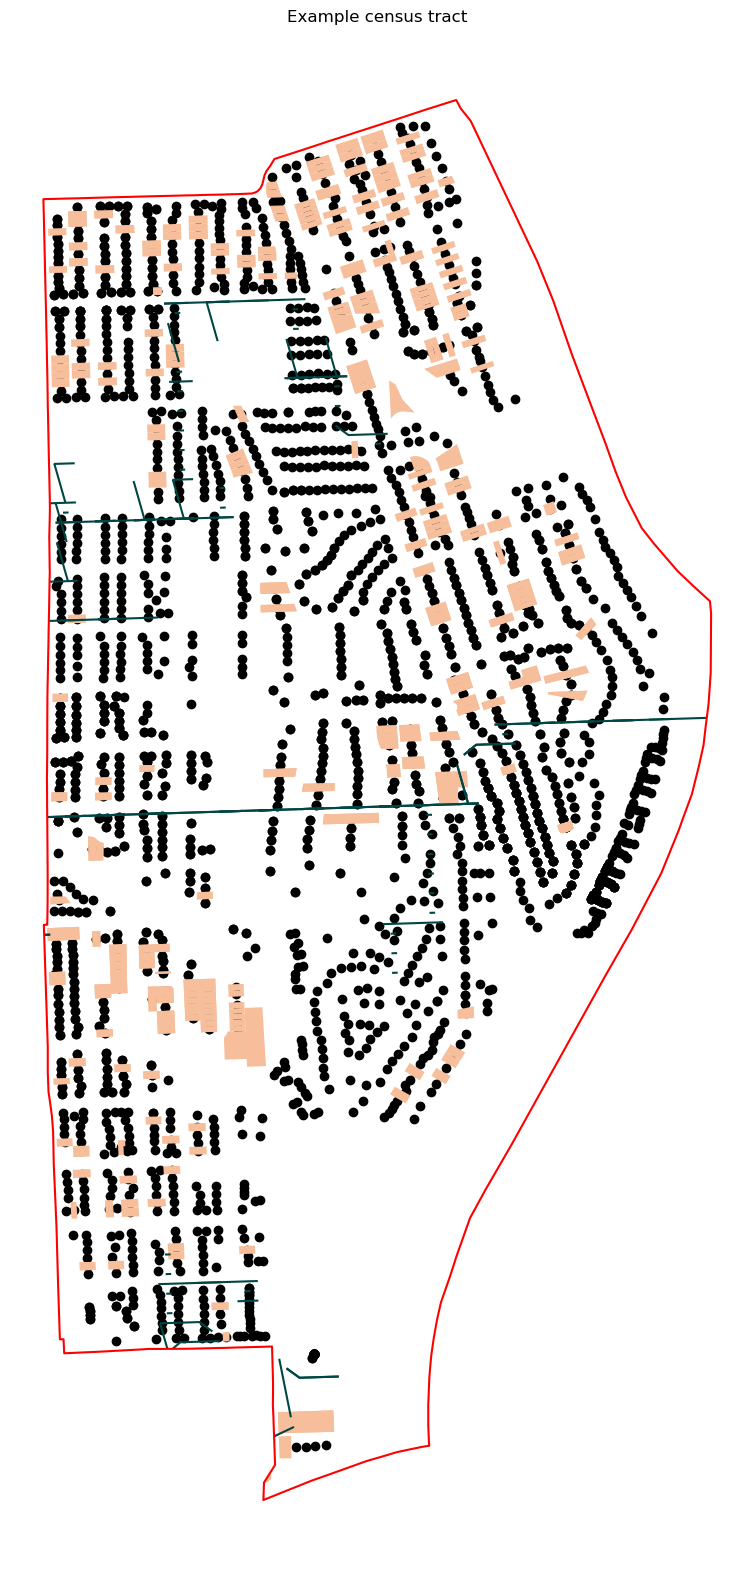

In [37]:
# plot all of the data sources to ensure just one census tract is present 
fig, ax = plt.subplots(figsize=(20, 20))

ax.axis('off')

example_singlefamily.plot(ax=ax, 
                    color='black')

example_multifamily.plot(ax=ax, 
                    color='#F6BE9A')

example_feeder.plot(ax=ax, 
                      color='#004643')

example_census.boundary.plot(ax=ax, 
                    color='red')

plt.title('Example census tract')

#### 1. View the maximum hosting capactiy
For this example let's look at the ICA with no operational flex uniform generation.

In [ ]:
# view the max ICA no operational flex 
print(example_singlefamily['ICAWNOF_UNIGENERATION'].max())
print(example_multifamily['ICAWNOF_UNIGENERATION'].max())
print(example_feeder['ICAWNOF_UNIGENERATION'].max())

5.7
5.7
5.7


The maximum ICA with no operational flex uniform generation are the same across the feederlines, the single family homes, and the multi-family homes. This is expected since the feederlines are connected to all of the residential buildings. 

In [45]:
# view the minimum ICA with no operational flex generation capacity 
print(example_singlefamily['ICAWNOF_UNIGENERATION'].min())
print(example_multifamily['ICAWNOF_UNIGENERATION'].min())
print(example_feeder['ICAWNOF_UNIGENERATION'].min())

0.1
0.1
0.1
